In [3]:
import pandas as pd

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [5]:
import os
print(os.getcwd())

c:\Users\abs\Desktop\CodeAlpha_CarPricePrediction\notebook


In [6]:
df = pd.read_csv("../dataset/car data.csv")

In [7]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [8]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB
None


In [9]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(2)

In [11]:
df = df.drop_duplicates()

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.shape

(299, 9)

In [14]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,299.000000,299.000000,299.000000,299.000000,299.000000
mean,2013.615385,4.589632,7.541037,36916.752508,0.043478
std,2.896868,4.984240,8.567887,39015.170352,0.248720
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.850000,1.200000,15000.000000,0.000000
50%,2014.000000,3.510000,6.100000,32000.000000,0.000000
75%,2016.000000,6.000000,9.840000,48883.500000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [15]:
df.corr(numeric_only=True)

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
Year,1.000000,0.234369,-0.053563,-0.525714,-0.181639
Selling_Price,0.234369,1.000000,0.876378,0.028566,-0.087880
Present_Price,-0.053563,0.876378,1.000000,0.205253,0.009947
Kms_Driven,-0.525714,0.028566,0.205253,1.000000,0.089367
Owner,-0.181639,-0.087880,0.009947,0.089367,1.000000


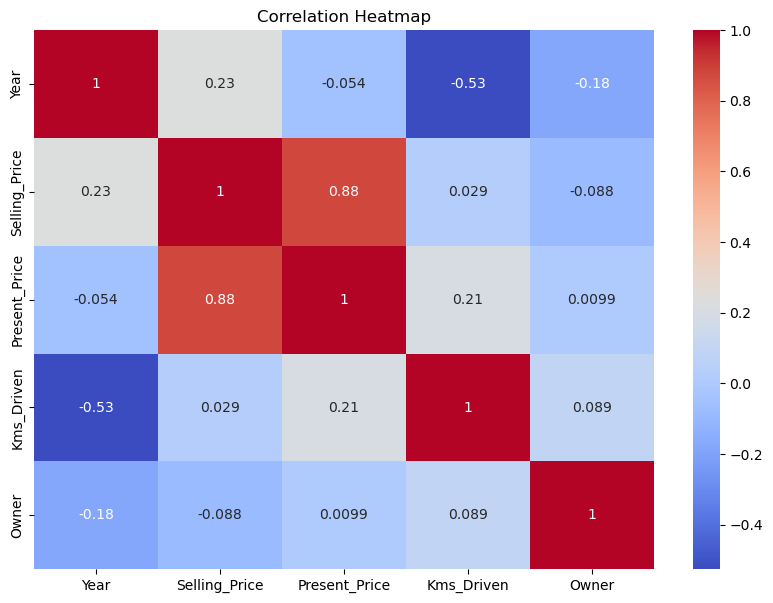

In [16]:
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

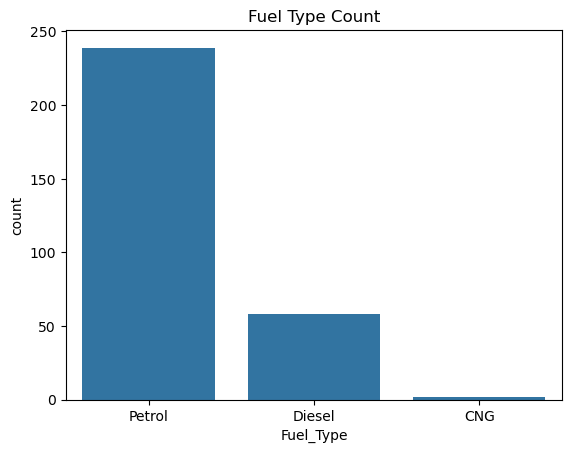

In [17]:
sns.countplot(x='Fuel_Type', data=df)

plt.title("Fuel Type Count")
plt.show()

In [18]:
print(df['Fuel_Type'].unique())
print(df['Seller_Type'].unique())
print(df['Transmission'].unique())

['Petrol' 'Diesel' 'CNG']
['Dealer' 'Individual']
['Manual' 'Automatic']


In [19]:
df = df.copy()

In [20]:
df['Fuel_Type'] = df['Fuel_Type'].map({
    'Petrol': 0,
    'Diesel': 1,
    'CNG': 2
})

df['Seller_Type'] = df['Seller_Type'].map({
    'Dealer': 0,
    'Individual': 1
})

df['Transmission'] = df['Transmission'].map({
    'Manual': 0,
    'Automatic': 1
})

In [21]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,0,0,0,0
1,sx4,2013,4.75,9.54,43000,1,0,0,0
2,ciaz,2017,7.25,9.85,6900,0,0,0,0
3,wagon r,2011,2.85,4.15,5200,0,0,0,0
4,swift,2014,4.60,6.87,42450,1,0,0,0


In [22]:
X = df.drop(['Car_Name', 'Selling_Price'], axis=1)

Y = df['Selling_Price']

In [23]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=2
)

In [24]:
X_train = X_train.dropna()
Y_train = Y_train[X_train.index]

In [25]:
model = LinearRegression()

In [26]:
model.fit(X_train, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [27]:
test_data_prediction = model.predict(X_test)

In [28]:
test_error_score = r2_score(Y_test, test_data_prediction)

print("R squared Error:", test_error_score)

R squared Error: 0.789503078133785


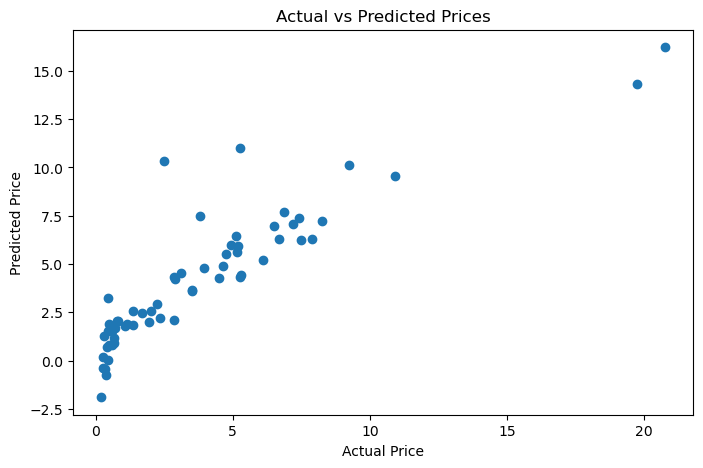

In [29]:
plt.figure(figsize=(8,5))

plt.scatter(Y_test, test_data_prediction)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Prices")

plt.show()

In [30]:
input_data = (5, 9.85, 0, 0, 0, 2017, 50000)

In [31]:
X.columns

Index(['Year', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type',
       'Transmission', 'Owner'],
      dtype='object')

In [32]:
input_data_as_numpy_array = np.asarray(input_data)

In [33]:
input_data_reshaped = input_data_as_numpy_array.reshape(1, -1)

In [34]:
input_data = pd.DataFrame({
    'Year': [2017],
    'Present_Price': [9.85],
    'Kms_Driven': [50000],
    'Fuel_Type': [0],
    'Seller_Type': [0],
    'Transmission': [0],
    'Owner': [0]
})

prediction = model.predict(input_data)

print("Predicted Car Price:", prediction[0])

Predicted Car Price: 6.8807700718047045


In [35]:
import joblib

joblib.dump(model, 'car_price_model.pkl')

['car_price_model.pkl']